# Gamma Distributed Clock Rate Prior for Ebola Bundibugyo


The Abbot et al (2026-05-27) used a two fixed clock rate priors of 1.2e-3 and 1.9e-3. The more recent [viroligcal post (2026-07-09)](https://virological.org/t/genomic-epidemiology-of-the-ongoing-2026-bundibugyo-virus-disease-outbreak-in-the-democratic-republic-of-the-congo/1045) suggests a clock rate of 1.095e-3. Lets use a gamma distributed prior with a mean of 1.095e-3 and an SD that covers 1.2e-3 and 1.9e-3.


Abbott, Sam, Katharine Sherratt, Samuel Brand, and Sebastian Funk. 2026. “Estimating the Current Size of the 2026 DRC Bundibugyo Virus Outbreak: A Joint Bayesian Re-Analysis of the McCabe et al. Report.” Zenodo, May 27 2026. https://epiforecasts.io/BVDOutbreakSize/dev/.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gamma, lognorm
import seaborn as sns

In [13]:
mean_target = 1.1e-3
std_target = 0.5e-3

## Gamma distribution

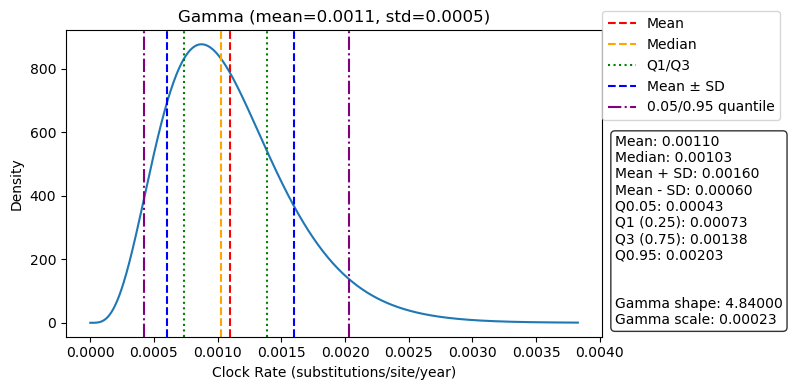

In [15]:
# Parameters for desired mean and std

shape = (mean_target / std_target) ** 2
scale = std_target ** 2 / mean_target
mu = shape * scale

x = np.linspace(0, mu + 12*scale, 500)
y = gamma.pdf(x, a=shape, scale=scale)

fig, ax = plt.subplots(figsize=(8, 4))
mean = gamma.mean(a=shape, scale=scale)
std = gamma.std(a=shape, scale=scale)
median = gamma.median(a=shape, scale=scale)
q1 = gamma.ppf(0.25, a=shape, scale=scale)
q3 = gamma.ppf(0.75, a=shape, scale=scale)
q05 = gamma.ppf(0.05, a=shape, scale=scale)
q95 = gamma.ppf(0.95, a=shape, scale=scale)

sns.lineplot(x=x, y=y, ax=ax)
ax.set_title(f"Gamma (mean={mean_target}, std={std_target})")
ax.set_xlabel("Clock Rate (substitutions/site/year)")
ax.set_ylabel("Density")
ax.axvline(mean, color="red", linestyle="--", label="Mean")
ax.axvline(median, color="orange", linestyle="--", label="Median")
ax.axvline(q1, color="green", linestyle=":", label="Q1/Q3")
ax.axvline(q3, color="green", linestyle=":", label=None)
ax.axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
ax.axvline(mean + std, color="blue", linestyle="--", label=None)
ax.axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
ax.axvline(q95, color="purple", linestyle="-.", label=None)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

stats_text = (
    f"Mean: {mean:.5f}\n"
    f"Median: {median:.5f}\n"
    f"Mean + SD: {(mean + std):.5f}\n"
    f"Mean - SD: {(mean - std):.5f}\n"
    f"Q0.05: {q05:.5f}\n"
    f"Q1 (0.25): {q1:.5f}\n"
    f"Q3 (0.75): {q3:.5f}\n"
    f"Q0.95: {q95:.5f}\n\n\n"
    f"Gamma shape: {shape:.5f}\n"
    f"Gamma scale: {scale:.5f}"
)

fig.text(
    0.775, 0.65, stats_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()
fig.savefig("gamma_epop_prior_2026-05-20.png", bbox_inches="tight")